<a href="https://colab.research.google.com/github/sitong0509/Beyond-Administrative-Boundaries-Measuring-Ethnic-Disparities-in-Violent-Crime-Exposure-in-London/blob/main/1_roadnetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1



In [ ]:
! pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import pandas as pd
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPolygon
from IPython.display import IFrame
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely import wkt
from shapely.geometry import MultiPoint
from shapely.geometry import mapping
from shapely import geometry, ops
from shapely.geometry import MultiLineString
from shapely.ops import linemerge
from itertools import combinations
from shapely.wkt import loads
ox.settings.use_cache = True
ox.settings.log_console = True
import geopy.distance
import math
import numpy as np
from tqdm import tqdm
from scipy.spatial.distance import cdist
from geopy.distance import great_circle
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 2

In [ ]:
lsoa_geometry = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_LSOA2021.shp')
lsoa_geometry = lsoa_geometry.to_crs('EPSG:4326')
lsoa_geometry

,LSOA21CD,LSOA21NM,GlobalID,geometry
0,E01000842,Camden 011A,9672d876-25b3-4797-8c35-8931e8610110,"POLYGON ((-0.16526 51.54729, -0.1646 51.54709,..."
1,E01000843,Camden 014A,ff8e83dc-84bd-47f4-b222-d75ffc735ad0,"POLYGON ((-0.16176 51.54869, -0.16043 51.54777..."
2,E01000844,Camden 011B,4a32d169-069b-4e6f-af55-b9d8746070b2,"POLYGON ((-0.17201 51.54657, -0.17061 51.54622..."
3,E01000845,Camden 014B,50465c31-d6b2-444f-89ef-9a1b2748d92e,"POLYGON ((-0.16027 51.5461, -0.15948 51.54566,..."
4,E01000846,Camden 014C,7ba87a06-21cd-44a5-bc84-5c0afc9cdf00,"POLYGON ((-0.16497 51.54481, -0.16478 51.54432..."
...,...,...,...,...
125,E01035708,Camden 022F,a3ddc6f2-bb81-4da6-a911-8893536aef4b,"POLYGON ((-0.13106 51.54212, -0.13071 51.54113..."
126,E01035709,Camden 022G,03cb43e8-2be6-424d-a41d-8bb298e17653,"POLYGON ((-0.12852 51.53679, -0.12636 51.53469..."
127,E01035710,Camden 023F,8619bf66-b5e3-4d93-8f5f-022280e9399a,"POLYGON ((-0.14093 51.53215, -0.14011 51.53178..."
128,E01035711,Camden 026E,bc7155f1-ed39-4249-88cf-59b039c519a5,"POLYGON ((-0.12873 51.52543, -0.12791 51.5247,..."


In [ ]:
merged_geometry_lsoa = lsoa_geometry.unary_union

exterior = Polygon(merged_geometry_lsoa.exterior)

merged_gdf = gpd.GeoDataFrame(geometry=[exterior], crs=lsoa_geometry.crs)

/tmp/ipykernel_1214/1177363452.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_geometry_lsoa = lsoa_geometry.unary_union


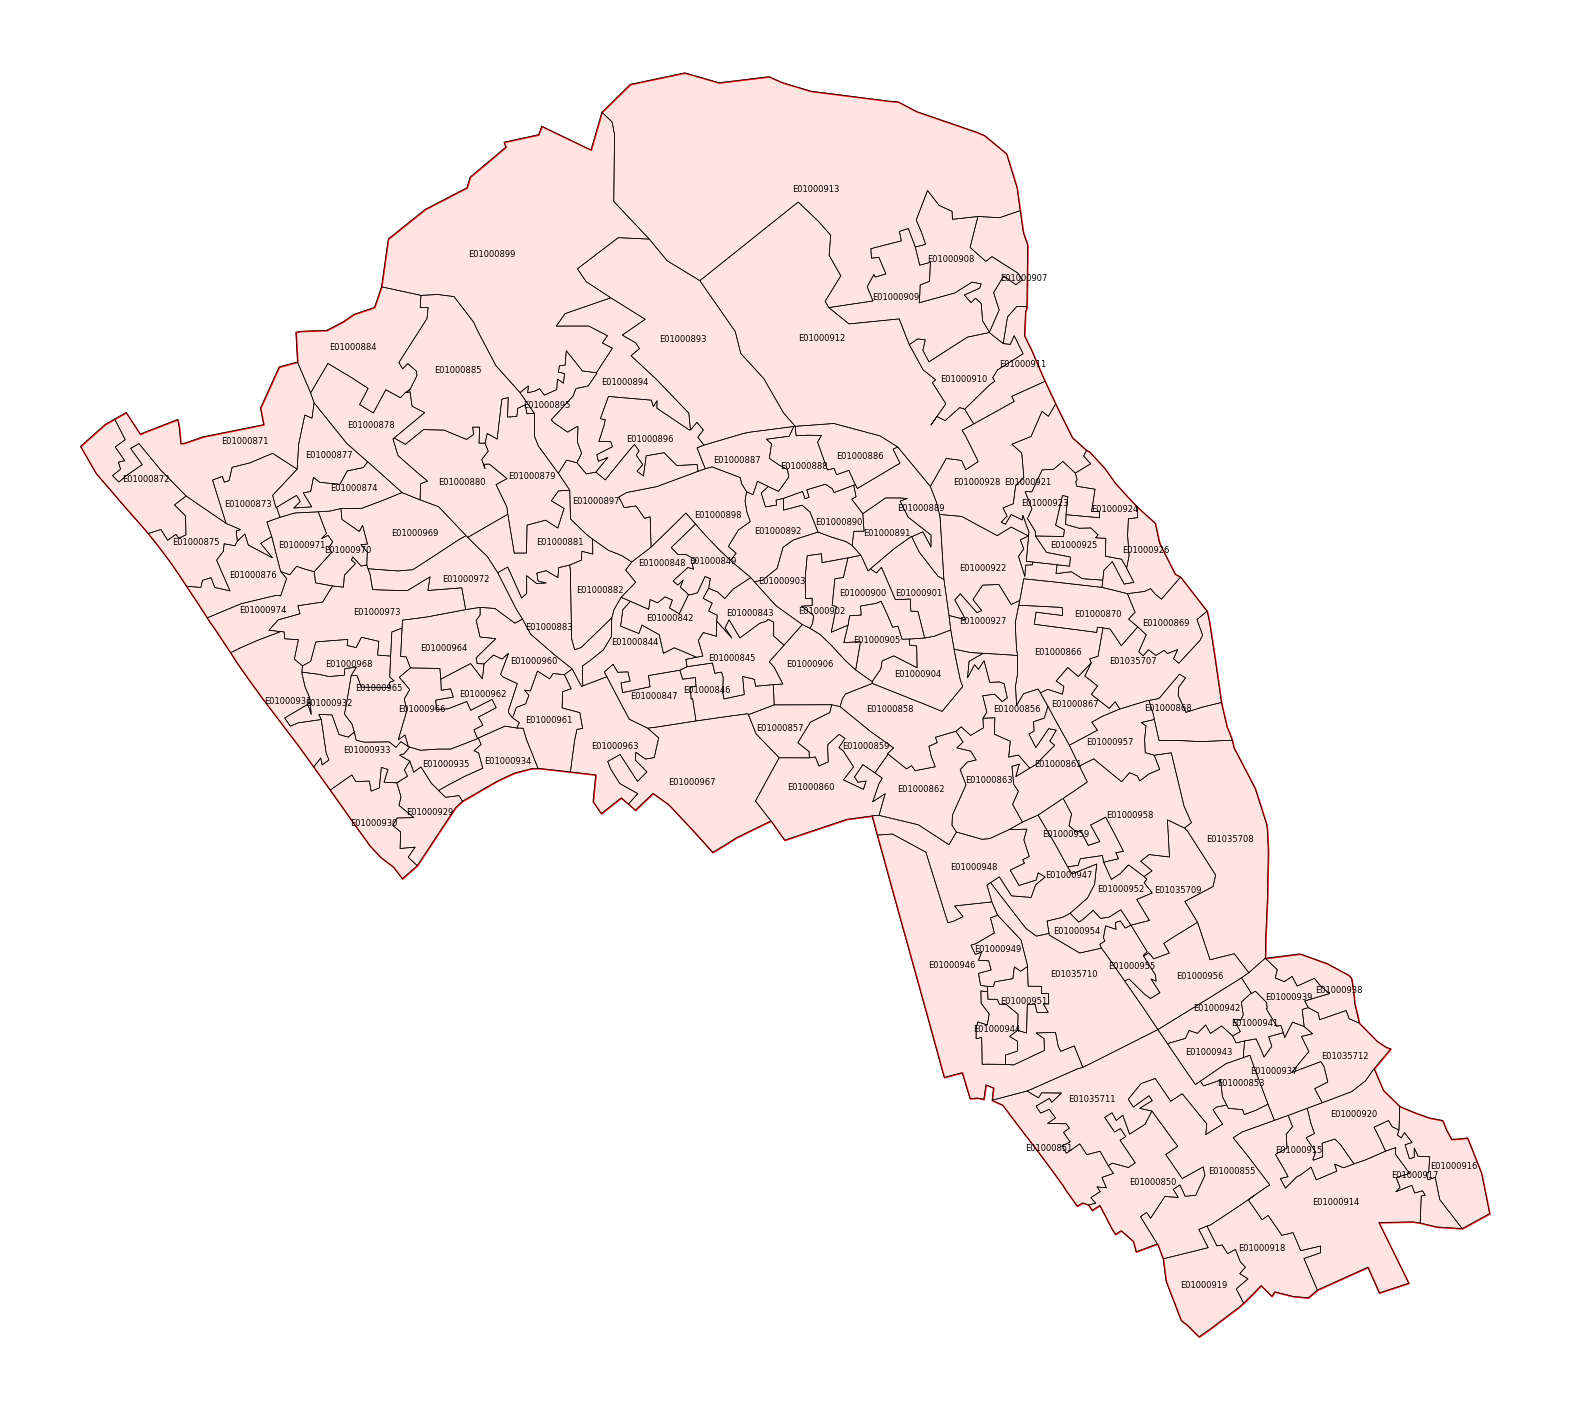

In [ ]:
fig, ax = plt.subplots(1, figsize=(20, 20))

polygon = gpd.GeoSeries([merged_gdf.iloc[0, 0]], crs='EPSG:4326')
polygon.plot(ax=ax, facecolor='mistyrose', edgecolor='red', linewidth=1, zorder=1)

lsoa_geometry.boundary.plot(ax=ax, color='black', linewidth=0.5, zorder=2)

# 标注 LSOA21CD
for _, r in lsoa_geometry.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(
        r['LSOA21CD'], xy=(p.x, p.y),
        ha='center', va='center', fontsize=6, zorder=3,
    )

ax.set_axis_off()
plt.show()

In [ ]:
buffer_dist = 1200  # （m）

# epsg=27700
gdf_proj = merged_gdf.copy().to_crs(epsg=27700)

gdf_proj['buffered_geom'] = gdf_proj.geometry.buffer(buffer_dist)

# epsg=4326
buffered_gdf = gdf_proj.set_geometry('buffered_geom').to_crs(epsg=4326)

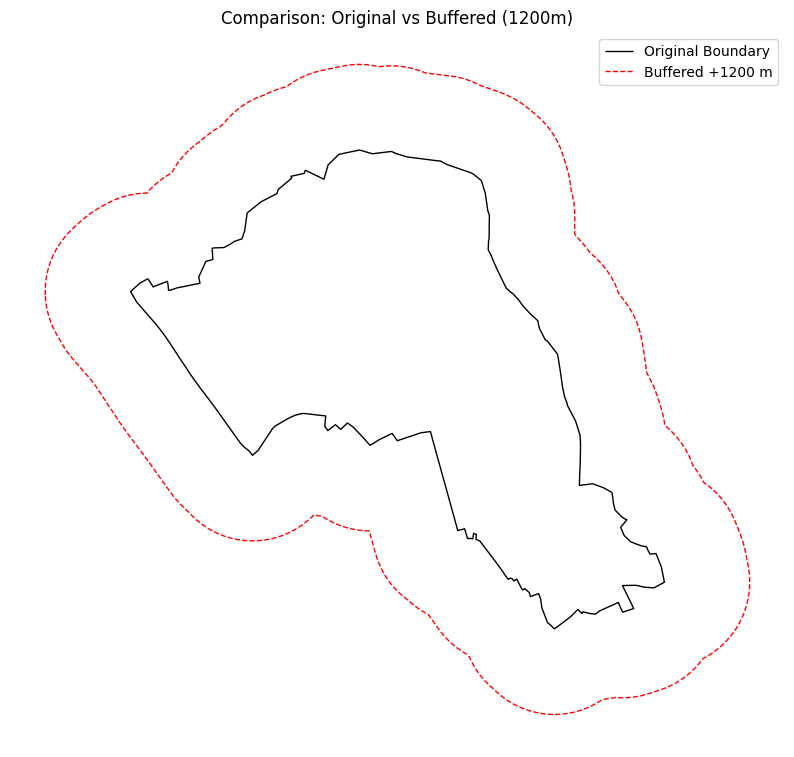

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_gdf.boundary.plot(ax=ax, color='black', linewidth=1, label='Original Boundary')

buffered_gdf.boundary.plot(
    ax=ax, color='red', linewidth=1, linestyle='--',
    label=f'Buffered +{buffer_dist:g} m'
)

plt.legend()
plt.title(f'Comparison: Original vs Buffered ({buffer_dist:g}m)')
plt.axis('off')
plt.show()

In [ ]:
buffered_gdf = buffered_gdf.to_crs(epsg=4326)

polygon = buffered_gdf.unary_union

G = ox.graph_from_polygon(polygon, network_type='walk', retain_all=True)

G = ox.project_graph(G, to_crs='EPSG:27700')

nodes, edges = ox.graph_to_gdfs(G)

/tmp/ipykernel_1214/2634731344.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = buffered_gdf.unary_union


In [ ]:
edges_proj = edges.to_crs(buffered_gdf.crs)

fig, ax = plt.subplots(figsize=(10, 10))
edges_proj.plot(ax=ax, linewidth=0.5, color='gray')
buffered_gdf.boundary.plot(ax=ax, color='red', linestyle='--')
plt.title('OSM Road Network within Buffered Area (Projected)')
plt.axis('off')
plt.show()

In [ ]:
from pathlib import Path

base_dir = Path('/content/drive/MyDrive/RQ2/github/Camden_roadnetwork')

out_dir = base_dir / f'Camden_road_{buffer_dist:g}m'

out_dir.mkdir(parents=True, exist_ok=True)

edges_path = out_dir / 'edges_buffered_WALK.geojson'
nodes_path = out_dir / 'nodes_buffered_WALK.geojson'

edges.to_file(edges_path, driver='GeoJSON')
nodes.to_file(nodes_path, driver='GeoJSON')

# 3

In [ ]:
pop_centroid_orig = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_pop_centroid.shp')
pop_centroid_orig = pop_centroid_orig[['LSOA21CD', 'geometry']]
pop_centroid = pop_centroid_orig.to_crs(epsg=27700)
pop_centroid

,LSOA21CD,geometry
0,E01000885,POINT (525969.678 185912.709)
1,E01000927,POINT (528801.584 184709.878)
2,E01000960,POINT (526292.971 184521.933)
3,E01000884,POINT (525397.951 186073.622)
4,E01000858,POINT (528562.252 184233.297)
...,...,...
125,E01000930,POINT (525597.484 183587.753)
126,E01000946,POINT (528853.866 182593.558)
127,E01000856,POINT (528952.794 184341.486)
128,E01000917,POINT (531124.937 181938.103)


In [ ]:
gdf = gpd.read_file('/content/drive/MyDrive/RQ2/github/Camden_LSOA2021/Camden_LSOA2021.shp')
gdf = gdf.to_crs(epsg=27700)

lsoa_geometry = gdf[['LSOA21CD', 'LSOA21NM', 'geometry']].copy()
lsoa_geometry = lsoa_geometry.merge(pop_centroid[['LSOA21CD', 'geometry']], on='LSOA21CD', how='left')
lsoa_geometry = lsoa_geometry.rename(columns={
    'geometry_x': 'geometry',
    'geometry_y': 'pop_centroid'
})

lsoa_geometry

,LSOA21CD,LSOA21NM,geometry,pop_centroid
0,E01000842,Camden 011A,"POLYGON ((527317.842 184750.587, 527364.385 18...",POINT (527165.138 184713.9)
1,E01000843,Camden 014A,"POLYGON ((527556.967 184912.235, 527651.276 18...",POINT (527516.095 184757.845)
2,E01000844,Camden 011B,"POLYGON ((526851.643 184658.668, 526949.695 18...",POINT (526924.327 184503.644)
3,E01000845,Camden 014B,"POLYGON ((527667.143 184626.554, 527723.353 18...",POINT (527497.529 184507.729)
4,E01000846,Camden 014C,"POLYGON ((527344.945 184475.174, 527359.264 18...",POINT (527348.595 184375.087)
...,...,...,...,...
125,E01035708,Camden 022F,"POLYGON ((529703.612 184235.068, 529731.064 18...",POINT (530143.786 183842.207)
126,E01035709,Camden 022G,"POLYGON ((529895.503 183647.069, 530051.002 18...",POINT (529760.397 183174.213)
127,E01035710,Camden 023F,"POLYGON ((529047.877 183109.537, 529105.459 18...",POINT (529167.875 182621.375)
128,E01035711,Camden 026E,"POLYGON ((529913.069 182383.448, 529971.74 182...",POINT (529693.502 182287.799)


In [ ]:
edges_path = '/content/drive/MyDrive/RQ2/github/Camden_roadnetwork/Camden_road_1200m/edges_buffered_WALK.geojson'
nodes_path = '/content/drive/MyDrive/RQ2/github/Camden_roadnetwork/Camden_road_1200m/nodes_buffered_WALK.geojson'

def ndarray_to_list(gdf):
    for col in gdf.columns:
        if col != gdf.geometry.name and gdf[col].dtype == object:
            gdf[col] = gdf[col].map(lambda v: v.tolist() if isinstance(v, np.ndarray) else v)
    return gdf

edges = ndarray_to_list(gpd.read_file(edges_path).to_crs('EPSG:27700'))
nodes = ndarray_to_list(gpd.read_file(nodes_path).to_crs('EPSG:27700'))

nodes['x'] = nodes.geometry.x
nodes['y'] = nodes.geometry.y
edges.set_index(['u', 'v', 'key'], inplace=True)
nodes.set_index('osmid', inplace=True)
G = ox.graph_from_gdfs(nodes, edges)

isolated_nodes = list(nx.isolates(G))
print(f"Number of isolated nodes: {len(isolated_nodes)}")

G_clean = G.copy()
G_clean.remove_nodes_from(isolated_nodes)

largest_cc = max(nx.weakly_connected_components(G_clean), key=len)
G_main = G_clean.subgraph(largest_cc).copy()

/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Number of isolated nodes: 43


# 4

## 1 test

In [ ]:
row = lsoa_geometry[lsoa_geometry['LSOA21CD'] == 'E01000963'].iloc[0]
centroid = row['pop_centroid']

In [ ]:
try:
    from shapely import union_all, set_precision, make_valid
    HAS_SHAPELY2 = True
except Exception:
    HAS_SHAPELY2 = False

In [ ]:
TARGET_TOTAL = 1200
SIDE_BUF     = 50
RADIUS       = TARGET_TOTAL - SIDE_BUF
PRECISION    = 0.1
QUAD_SEGS    = 4

def remove_holes(geom):
    if geom is None or geom.is_empty:
        return geom
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    if geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms if not p.is_empty])
    return geom

def dissolve_lines(lines):
    items = [g for g in lines if g and not g.is_empty]
    if not items:
        return None
    if HAS_SHAPELY2:
        return linemerge(union_all(items))
    else:
        return linemerge(unary_union(items))

def n_vertices(geom):
    if geom is None or geom.is_empty:
        return 0
    if geom.geom_type == 'Polygon':
        return len(geom.exterior.coords)
    if geom.geom_type == 'MultiPolygon':
        return sum(len(p.exterior.coords) for p in geom.geoms)
    return 0

In [ ]:
origin_node = ox.distance.nearest_nodes(G_main, centroid.x, centroid.y)
subgraph = nx.ego_graph(
    G_main, origin_node, radius=RADIUS, distance='length', undirected=True
)

edges_sub = ox.graph_to_gdfs(subgraph, nodes=False)

merged = dissolve_lines(edges_sub.geometry.values)

if HAS_SHAPELY2 and (PRECISION is not None):
    merged = set_precision(merged, PRECISION)

try:
    # Shapely 2.x
    network_buffer_geom = merged.buffer(SIDE_BUF, quad_segs=QUAD_SEGS)
except TypeError:
    # Shapely 1.x
    network_buffer_geom = merged.buffer(SIDE_BUF, resolution=QUAD_SEGS)

if HAS_SHAPELY2:
    network_buffer_geom = make_valid(network_buffer_geom)

# network_buffer_geom2 = remove_holes(network_buffer_geom)

len_centerline_m = float(merged.length)

In [ ]:
nb_gdf = gpd.GeoDataFrame(
    {
        'LSOA21CD': [row['LSOA21CD']],
        'LSOA21NM': [row['LSOA21NM']],
        'radius_net': [RADIUS],
        'side_buffer': [SIDE_BUF],
        'buffer_total': [TARGET_TOTAL],
        'len_centerline_m': [len_centerline_m],
        'geometry': [network_buffer_geom],
    },
    crs='EPSG:27700',
)

nb_gdf

,LSOA21CD,LSOA21NM,radius_net,side_buffer,buffer_total,len_centerline_m,geometry
0,E01000963,Camden 017C,1150,50,1200,63756.660789,"POLYGON ((525747.5 183876, 525745 183882.8, 52..."


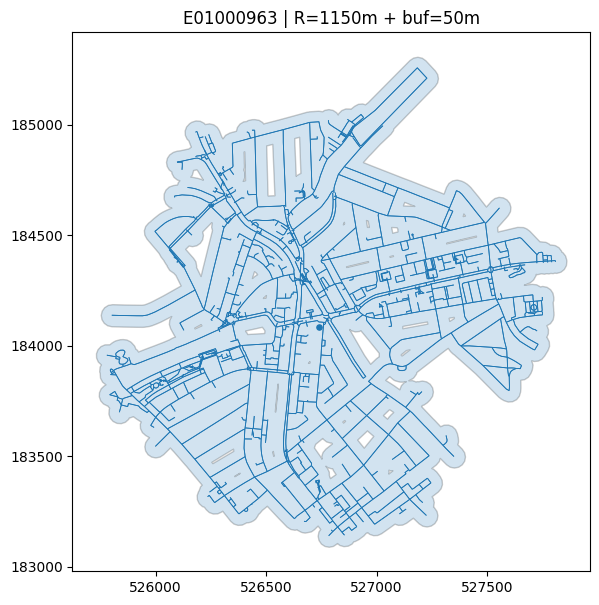

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
nb_gdf.plot(ax=ax, alpha=0.2, edgecolor='black', linewidth=1.0)
edges_sub.plot(ax=ax, linewidth=0.6)
ax.scatter([centroid.x], [centroid.y], s=14)
ax.set_aspect('equal')
ax.set_title(f'{row['LSOA21CD']} | R={RADIUS}m + buf={SIDE_BUF}m')
plt.show()

## 2 all

In [ ]:
output_dir = '/content/drive/MyDrive/RQ2/github/Camden_road_buffer'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'Camden_road_buffer.shp')

results = []
fail_logs = []

for idx, row in tqdm(lsoa_geometry.iterrows(), total=len(lsoa_geometry)):
    lsoa_id   = row['LSOA21CD']
    lsoa_name = row['LSOA21NM']
    centroid  = row['pop_centroid']  # EPSG:27700

    status = 'ok'
    geom_out = None
    dist_to_node = None
    len_centerline_m = None

    try:
        origin_node = ox.distance.nearest_nodes(G_main, centroid.x, centroid.y)
        nearest_geom = Point(G_main.nodes[origin_node]['x'], G_main.nodes[origin_node]['y'])
        dist_to_node = float(centroid.distance(nearest_geom))

        subgraph = nx.ego_graph(G_main, origin_node, radius=RADIUS, distance='length', undirected=True)

        edges_sub = ox.graph_to_gdfs(subgraph, nodes=False)

        merged = dissolve_lines(list(edges_sub.geometry.values))

        if HAS_SHAPELY2 and (PRECISION is not None):
            merged = set_precision(merged, PRECISION)

        try:
            network_buf = merged.buffer(SIDE_BUF, quad_segs=QUAD_SEGS)
        except TypeError:
            network_buf = merged.buffer(SIDE_BUF, resolution=QUAD_SEGS)

        if HAS_SHAPELY2:
            network_buf = make_valid(network_buf)
        geom_out = network_buf
        verts = n_vertices(geom_out)

        len_centerline_m = float(merged.length)

    except Exception as e:
        status = f'fail: {type(e).__name__}'
        fail_logs.append((lsoa_id, lsoa_name, str(e)))


    # 记录结果（无论成败）
    results.append({
        'LSOA21CD':        lsoa_id,
        'LSOA21NM':        lsoa_name,
        'p_centroid':      centroid,
        'buf_total':       TARGET_TOTAL,
        'buf_side':        SIDE_BUF,
        'buf_radius':      RADIUS,
        'd_to_node':       dist_to_node,
        'road_len':        len_centerline_m,
        'geometry':        geom_out,
    })

100%|██████████| 130/130 [35:27<00:00, 16.36s/it]


In [ ]:
buffer_gdf = gpd.GeoDataFrame(results, crs='EPSG:27700')
buffer_gdf.to_file(output_path, index=False)

In [ ]:
print('fail:', fail_logs)
print(buffer_gdf['d_to_node'].describe())
print(buffer_gdf.nsmallest(5, 'road_len')[['LSOA21CD', 'd_to_node', 'road_len']])

fail: []
count    130.000000
mean      32.914653
std       25.203179
min        0.895123
25%       15.647668
50%       25.473204
75%       45.048254
max      113.100096
Name: d_to_node, dtype: float64
      LSOA21CD  d_to_node      road_len
122  E01000973  14.822690  18695.769767
123  E01000974  76.690919  22932.655305
30   E01000876  46.954970  24908.917716
118  E01000969  79.373607  27157.277663
67   E01000913  75.084231  27650.752496
